# **Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('Libraries Loaded')

Libraries Loaded


# **Data Exploration**

## **Load The data**

In [2]:
path = input("enter the Data Path: ")
path = path.replace("\\",'\\')

df = pd.read_csv(path)
print('Data Loaded')

Data Loaded


## *Exploration*

In [3]:
df.head()

,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Stress_Level,Sleep_Hours,Caffeine_mg,Calories_Consumed,Protein_g,Carbs_g,Fat_g,Steps,Workout_Type,Workout_Intensity,Temp_C,Weight_Change,Current_Weight_kg
0,275,23,Female,169.355325,111.485330,10,7.016453,211.426469,2801.764291,175.1,315.2,93.4,8172,Strength,6,18.823955,0.317158,111.802488
1,296,43,Female,174.424939,109.699334,1,7.320227,211.979739,2666.001616,166.6,299.9,88.9,7988,NaN,0,36.987432,0.211877,109.911211
2,125,47,Male,163.246320,110.960286,3,7.238641,160.400067,1707.084012,106.7,192.0,56.9,7976,Yoga,10,35.977033,0.122390,111.082676
3,167,42,Female,164.997333,85.546097,7,5.060697,301.629856,2647.458547,165.5,297.8,88.2,8203,Cardio,10,33.141805,0.308449,85.854547
4,311,54,Male,167.696168,135.710505,5,9.866791,335.199126,2036.567163,127.3,229.1,67.9,8024,NaN,0,19.065076,0.120221,135.830726


In [4]:
df.shape

(55000, 18)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            55000 non-null  int64  
 1   Age                55000 non-null  int64  
 2   Gender             55000 non-null  str    
 3   Height_cm          55000 non-null  float64
 4   Initial_Weight_kg  55000 non-null  float64
 5   Stress_Level       55000 non-null  int64  
 6   Sleep_Hours        55000 non-null  float64
 7   Caffeine_mg        55000 non-null  float64
 8   Calories_Consumed  52250 non-null  float64
 9   Protein_g          55000 non-null  float64
 10  Carbs_g            55000 non-null  float64
 11  Fat_g              55000 non-null  float64
 12  Steps              55000 non-null  int64  
 13  Workout_Type       27448 non-null  str    
 14  Workout_Intensity  55000 non-null  int64  
 15  Temp_C             55000 non-null  float64
 16  Weight_Change      55000 non-null

In [6]:
df.describe()

,User_ID,Age,Height_cm,Initial_Weight_kg,Stress_Level,Sleep_Hours,Caffeine_mg,Calories_Consumed,Protein_g,Carbs_g,Fat_g,Steps,Workout_Intensity,Temp_C,Weight_Change,Current_Weight_kg
count,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,52250.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000
mean,349.441400,40.918545,169.972335,114.999924,5.524964,6.666340,261.091734,2097.729693,131.073911,235.932955,69.906169,7999.830891,3.496091,24.998172,0.168459,124.480910
std,144.343054,13.539751,9.991794,17.291936,2.881427,1.543146,114.579046,601.919105,37.583689,67.650694,20.044495,89.285148,3.776365,7.992403,0.105259,18.257341
min,100.000000,18.000000,126.190233,85.000325,1.000000,3.000000,0.000000,-327.404484,-20.500000,-36.800000,-10.900000,7632.000000,0.000000,-6.075821,-0.250723,85.327609
25%,224.000000,29.000000,163.273360,100.032148,3.000000,5.610998,181.968341,1693.339924,105.800000,190.500000,56.400000,7939.000000,0.000000,19.609512,0.096170,109.458941
50%,350.000000,41.000000,169.984098,115.032495,6.000000,6.659498,260.645919,2095.328161,130.900000,235.600000,69.800000,7999.000000,0.000000,24.996455,0.168383,124.555885
75%,474.000000,53.000000,176.675947,129.899387,8.000000,7.714812,339.196616,2501.645667,156.300000,281.325000,83.400000,8060.000000,7.000000,30.411654,0.241079,139.369026
max,599.000000,64.000000,213.837588,144.998228,10.000000,11.000000,740.175153,4874.404173,304.700000,548.400000,162.500000,8365.000000,10.000000,58.914302,0.593711,291.842383


In [7]:
df.isna().sum()

User_ID                  0
Age                      0
Gender                   0
Height_cm                0
Initial_Weight_kg        0
Stress_Level             0
Sleep_Hours              0
Caffeine_mg              0
Calories_Consumed     2750
Protein_g                0
Carbs_g                  0
Fat_g                    0
Steps                    0
Workout_Type         27552
Workout_Intensity        0
Temp_C                   0
Weight_Change            0
Current_Weight_kg        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

# **Data Cleaning**

In [9]:
df_copy = df.copy()

In [10]:
# DataType is all correct so we gonna skip that part

#OutLiers handaling

Outliers = ['Height_cm','Initial_Weight_kg','Sleep_Hours','Caffeine_mg','Calories_Consumed','Protein_g','Carbs_g'
            ,'Fat_g','Temp_C','Weight_Change','Current_Weight_kg']

for col in Outliers:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[
        (df_copy[col] < lower) | (df_copy[col] > upper),
        col
    ] = np.nan
    
print("OutLiers Handeled")

OutLiers Handeled


In [11]:
print('NaN values Before: ')
print(df_copy.isna().sum())

NaN_values = ['Height_cm','Initial_Weight_kg','Sleep_Hours','Caffeine_mg','Calories_Consumed','Protein_g','Carbs_g'
            ,'Fat_g','Temp_C','Weight_Change','Current_Weight_kg']

for NaN in NaN_values:
    df_copy[NaN] = df_copy[NaN].fillna(round(df_copy[NaN].median(),4))

df_copy['Workout_Type'] = df_copy['Workout_Type'].fillna('Unkown')
print('NaN values After: ')
print(df_copy.isna().sum())

NaN values Before: 
User_ID                  0
Age                      0
Gender                   0
Height_cm              382
Initial_Weight_kg        0
Stress_Level             0
Sleep_Hours            189
Caffeine_mg            160
Calories_Consumed     3123
Protein_g              392
Carbs_g                395
Fat_g                  381
Steps                    0
Workout_Type         27552
Workout_Intensity        0
Temp_C                 376
Weight_Change          281
Current_Weight_kg       10
dtype: int64
NaN values After: 
User_ID              0
Age                  0
Gender               0
Height_cm            0
Initial_Weight_kg    0
Stress_Level         0
Sleep_Hours          0
Caffeine_mg          0
Calories_Consumed    0
Protein_g            0
Carbs_g              0
Fat_g                0
Steps                0
Workout_Type         0
Workout_Intensity    0
Temp_C               0
Weight_Change        0
Current_Weight_kg    0
dtype: int64


In [12]:
df_copy.drop_duplicates(inplace=True)

# **EDA**

**Q1. What is the average age, sleep hours, steps, and calories consumed across all users?**

In [13]:
df_avg = df_copy.groupby('User_ID')[['Age','Sleep_Hours','Steps','Calories_Consumed']].mean().round(3)
df_avg['Age'] = df_avg['Age'].astype('int64')
df_avg.reset_index(inplace=True)
df_avg.head()

,User_ID,Age,Sleep_Hours,Steps,Calories_Consumed
0,100,41,6.581,7995.833,2066.048
1,101,40,6.551,8014.991,2147.673
2,102,41,6.454,7987.727,2161.230
3,103,39,6.484,8002.415,2025.022
4,104,41,6.640,8015.910,2081.843


**Q2. What is the gender distribution in the dataset?**

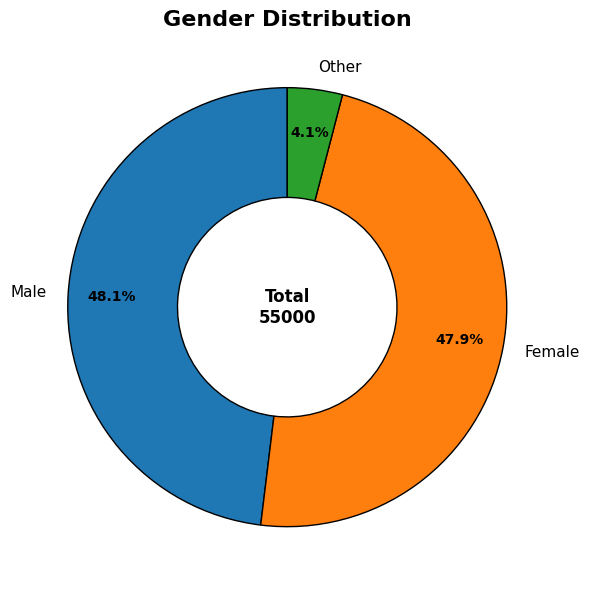

In [14]:
df_gen = df_copy['Gender'].value_counts()

fig, ax = plt.subplots(figsize=(6,6))

wedges, texts, autotexts = ax.pie(
    df_gen.values,
    labels=df_gen.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.5, 'edgecolor':'black'},
    pctdistance=0.8
)

# Improve text styling
for text in texts:
    text.set_fontsize(11)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

# Center text (nice touch)
ax.text(0, 0, f"Total\n{df_gen.sum()}",
        ha='center', va='center', fontsize=12, weight='bold')

ax.set_title("Gender Distribution", fontsize=16, weight='bold')
ax.axis('equal')

plt.tight_layout()
plt.show()

**Q3. Which workout type is most common?**

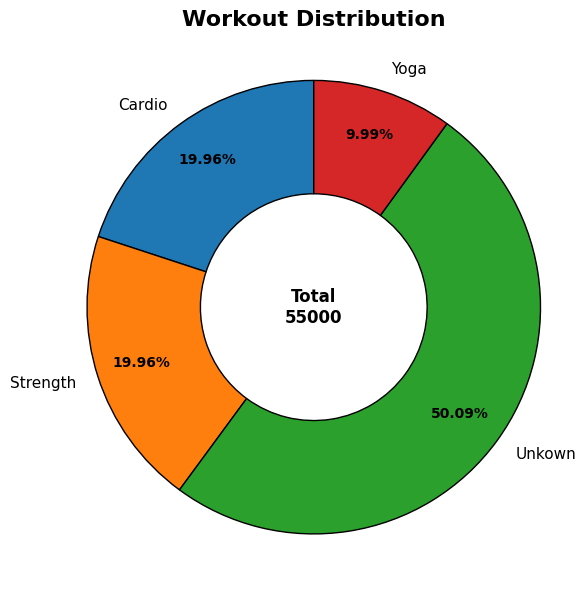

In [15]:
# df_workout = df_copy[df_copy['Workout_Type']!='Unkown']
df_workout = df_copy
df_workout = df_workout.groupby('Workout_Type')['Workout_Type'].size()
df_workout

fig, ax = plt.subplots(figsize=(6,6))

wedges, texts, autotexts = ax.pie(
    df_workout.values,
    labels=df_workout.index,
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops={'width':0.5, 'edgecolor':'black'},
    pctdistance=0.8
)

# Improve text styling
for text in texts:
    text.set_fontsize(11)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

# Center text (nice touch)
ax.text(0, 0, f"Total\n{df_workout.sum()}",
        ha='center', va='center', fontsize=12, weight='bold')

ax.set_title("Workout Distribution", fontsize=16, weight='bold')
ax.axis('equal')

plt.tight_layout()
plt.show()

**Q4. What is the average weight change per workout type — which workout leads to the most weight loss?**

In [16]:
df_weight_loss = df_copy.groupby('Workout_Type')['Weight_Change'].mean().sort_values(ascending=False)
df_weight_loss = pd.DataFrame(df_weight_loss).reset_index()
df_weight_loss.rename(columns={'Weight_Change': 'Avg_Weight_Change'}, inplace=True)
df_weight_loss

,Workout_Type,Avg_Weight_Change
0,Strength,0.169177
1,Yoga,0.168813
2,Unkown,0.168322
3,Cardio,0.168063


**Q5. Do people who sleep more lose more weight? Group sleep hours into buckets and compare avg weight change.**

In [17]:
bins = [0, 6, 8, 12]   
labels = ['Low (0-6)', 'Normal (6-8)', 'Over (8+)']
df_sleep =df_copy

df_sleep['Sleep_Category'] = pd.cut(
    df_sleep['Sleep_Hours'],
    bins=bins,
    labels=labels
)

df_sleep = pd.DataFrame(df_sleep.groupby('Sleep_Category')['Weight_Change'].mean().sort_values(ascending=False)).reset_index()
df_sleep

,Sleep_Category,Weight_Change
0,Low (0-6),0.186930
1,Normal (6-8),0.164407
2,Over (8+),0.146456


**Q6. What is the average calories consumed per stress level — do stressed people eat more?**

In [18]:
df_stress = pd.DataFrame(df_copy.groupby('Stress_Level')['Calories_Consumed'].mean().round(2).sort_values(ascending=False)).reset_index()
df_stress
# Yes, Stressed People consued more food compared to others

,Stress_Level,Calories_Consumed
0,9,2110.77
1,6,2107.78
2,10,2105.60
3,4,2094.56
4,3,2094.54
5,1,2093.97
6,8,2093.59
7,7,2093.20
8,5,2090.16
9,2,2086.66


**Q7. Which age group has the highest average steps per day? (create age buckets: 18–25, 26–35, 36–45, 46+)**

In [24]:
bins = [0, 18, 25, 35, 45, df_copy['Age'].max()]
labels = ['Children','Young','Adult','Mid-Age','Older']

df_age = df_copy.copy()

df_age["Age_Category"] = pd.cut(
    df_age['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_age = pd.DataFrame(df_age.groupby('Age_Category')['Steps'].mean().sort_values(ascending=False).astype('int')).reset_index()
df_age.rename(columns={'Steps': 'Avg_Steps'}, inplace=True)
df_age

,Age_Category,Avg_Steps
0,Older,8000
1,Mid-Age,7999
2,Young,7999
3,Adult,7999
4,Children,7996


**Q8. Is there a correlation between steps and weight change? (use .corr() and a scatter plot)**

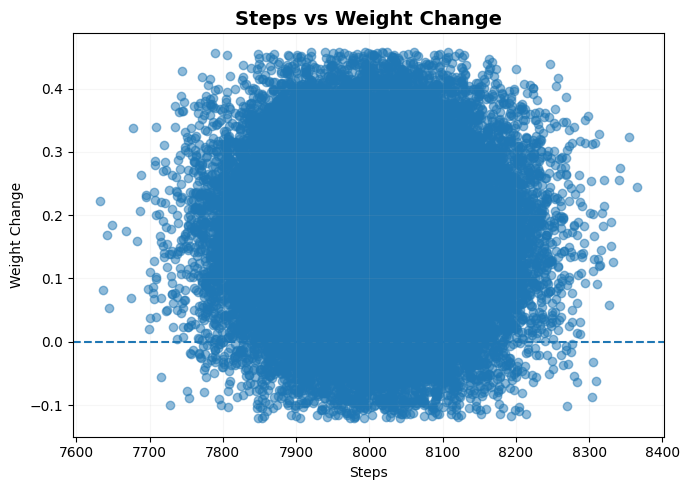

In [29]:
corr = df_copy[['Steps','Weight_Change']].corr()

plt.figure(figsize=(7,5))

plt.scatter(
    df_copy['Steps'],
    df_copy['Weight_Change'],
    alpha=0.5
)

plt.axhline(0, linestyle='--')  # weight gain vs loss line

plt.xlabel("Steps")
plt.ylabel("Weight Change")
plt.title("Steps vs Weight Change", fontsize=14, weight='bold')

plt.grid(alpha=0.1)
plt.tight_layout()
plt.show()